# Adding more data and compare measures

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import os
from itertools import product

from tqdm import tqdm

In [2]:
# Moving to parent directory to import from CDFD and other_helpers
current_dir = os.getcwd()
os.chdir("..")
from CDFD import get_circularity, CDFD
from other_helpers import  uniform_multigraph, in_cycle_ratio, trophic_incoherence,finn_cycling_index_sparse
from scipy.sparse import lil_array, csr_array, diags_array, coo_array, identity, csr_matrix, eye
# Moving back to original directory
os.chdir(current_dir)

### migration data

In [3]:
records = []
base_dir = 'data_government'

for sub in tqdm(os.listdir(base_dir)):
    folder = os.path.join(current_dir,base_dir, sub)
    if not os.path.isdir(folder):
        continue
    if 'edges.txt' not in os.listdir(folder):
        continue

    # --- load edges only; nodes inferred automatically ---
    edges = pd.read_csv(
        os.path.join(folder,'edges.txt'),
        sep='\t', engine='python'
    )
    G = nx.DiGraph()
    for _, row in edges.iterrows():
        u, v = int(row.Src), int(row.Trg)
        G.add_edge(u, v, weight=float(row.LinkCount))

    # --- infer node list (sorted for reproducibility) ---
    nodes = sorted(G.nodes())

    # --- compute measures ---
    incoh    = trophic_incoherence(G)
    incyc    = in_cycle_ratio(G)
    W        = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
    x        = W.sum(axis=0)
    # fci      = finn_cycling_index_sparse(csr_matrix(W), x)
    C1, D1   = CDFD(G, solution_method='min_cost_pulp')
    circ_max = get_circularity(C1, D1)
    C2, D2   = CDFD(G, solution_method='BFF')
    circ_bff = get_circularity(C2, D2)

    records.append({
        'folder':         sub,
        'incoherence':    incoh,
        'in_cycle_ratio': incyc,
        # 'fci':            fci,
        'circ_max':       circ_max,
        'circ_bff':       circ_bff
    })


  0%|                                     | 0/55 [00:00<?, ?it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/1709f68e20124771b6a51db2f521571b-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/1709f68e20124771b6a51db2f521571b-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 1045 COLUMNS
At line 30977 RHS
At line 32018 BOUNDS
At line 41996 ENDATA
Problem MODEL has 1040 rows, 9977 columns and 19954 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 595 (-445) rows, 7162 (-2815) columns and 14324 (-5630) elements
Perturbing problem by 0.001% of 3 - largest nonzero change 6.0811993e-05 ( 0.0056497849%) - largest zero change 4.6850264e-05
0  Obj 530894.38 Primal inf 88408.286 (586)
86  Obj 584957.37 Primal i

  4%|█                            | 2/55 [00:01<00:29,  1.77it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/3f5d433f81924c50923dc40d5c563c1f-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/3f5d433f81924c50923dc40d5c563c1f-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 352 COLUMNS
At line 4544 RHS
At line 4892 BOUNDS
At line 6290 ENDATA
Problem MODEL has 347 rows, 1397 columns and 2794 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 136 (-211) rows, 876 (-521) columns and 1752 (-1042) elements
Perturbing problem by 0.001% of 3 - largest nonzero change 5.8176759e-05 ( 0.0056447641%) - largest zero change 0
0  Obj 81693.356 Primal inf 6494.8043 (135)
46  Obj 85417.332 Primal inf 927.60137 (109)
12

  7%|██                           | 4/55 [00:01<00:19,  2.66it/s]

...

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/8bf7357259fa4aaab37c2c666451c583-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/8bf7357259fa4aaab37c2c666451c583-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 372 COLUMNS
At line 14305 RHS
At line 14673 BOUNDS
At line 19318 ENDATA
Problem MODEL has 367 rows, 4644 columns and 9288 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 210 (-157) rows, 3135 (-1509) columns and 6270 (-3018) elements
Perturbing problem by 0.001% of 2 - largest nonzero change 5.8488022e-05 ( 0.0055962401%) - largest zero change 0
0  Obj 238472.42 Primal inf 57994.207 (209)
79  Obj 275761.92 Primal inf 9307.1015 (17

 95%|██████████████████████████▍ | 52/55 [00:49<00:01,  1.78it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/c29aeffc4ef34d768b08a6892f806cb2-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/c29aeffc4ef34d768b08a6892f806cb2-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 3590 COLUMNS
At line 156285 RHS
At line 159871 BOUNDS
At line 210770 ENDATA
Problem MODEL has 3585 rows, 50898 columns and 101796 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 1885 (-1700) rows, 39324 (-11574) columns and 78648 (-23148) elements
Perturbing problem by 0.001% of 3 - largest nonzero change 6.1408612e-05 ( 0.0056499673%) - largest zero change 4.9148156e-05
0  Obj 4029964.6 Primal inf 659995.93 (1872)
112  Obj 437400

100%|████████████████████████████| 55/55 [01:20<00:00,  1.46s/it]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/53e3a89fba6c47b1a2623da6f7aa70dc-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/53e3a89fba6c47b1a2623da6f7aa70dc-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 270 COLUMNS
At line 6694 RHS
At line 6960 BOUNDS
At line 9102 ENDATA
Problem MODEL has 265 rows, 2141 columns and 4282 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 182 (-83) rows, 1857 (-284) columns and 3714 (-568) elements
Perturbing problem by 0.001% of 2 - largest nonzero change 5.8300522e-05 ( 0.0055948105%) - largest zero change 0
0  Obj 112142.49 Primal inf 15630.008 (179)
78  Obj 121956.3 Primal inf 1252.2002 (129)
154 

In [4]:
# build DataFrame and save
df = pd.DataFrame(records)
df.to_csv('migration_analysis.csv', index=False)
df.head()

,folder,incoherence,in_cycle_ratio,circ_max,circ_bff
0,missouri,0.160074,0.720048,0.082940,0.074211
1,southdakota,0.265364,0.855481,0.158667,0.146585
2,alaska,0.155614,0.550183,0.079233,0.067318
3,newhampshire,0.048299,0.467825,0.007456,0.007027
4,illinois,0.077096,0.753532,0.048529,0.046651


In [5]:
records_fw = []
base_dir_fw = 'data_foodweb'

for fname in tqdm(os.listdir(base_dir_fw)):
    if not fname.endswith('.txt'):
        continue
    path = os.path.join(base_dir_fw, fname)
    
    # load edges: no header, whitespace‐delim, quotes around names
    edges = pd.read_csv(
        path,
        sep=r'\s+',
        header=None,
        names=['Src','Trg','Weight'],
        engine='python'
    )
    # strip quotes
    edges['Src'] = edges['Src'].str.strip('"')
    edges['Trg'] = edges['Trg'].str.strip('"')

    # build directed graph
    G = nx.DiGraph()
    for u, v, w in zip(edges.Src, edges.Trg, edges.Weight):
        G.add_edge(u, v, weight=float(w))

    # sorted node list for matrix consistency
    nodes = sorted(G.nodes())

    # compute measures
    incoh    = trophic_incoherence(G)
    incyc    = in_cycle_ratio(G)
    W        = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
    x        = W.sum(axis=0)
    # fci      = finn_cycling_index_sparse(csr_matrix(W), x,solver='spsolver',eps=0)
    C1, D1   = CDFD(G, solution_method='min_cost_pulp')
    circ_max = get_circularity(C1, D1)
    C2, D2   = CDFD(G, solution_method='BFF')
    circ_bff = get_circularity(C2, D2)

    records_fw.append({
        'file':           fname,
        'incoherence':    incoh,
        'in_cycle_ratio': incyc,
        # 'fci':            fci,
        'circ_max':       circ_max,
        'circ_bff':       circ_bff
    })



  6%|█▊                           | 6/94 [00:00<00:03, 28.65it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/f29bb4f4497043fe8642ea057004a8c7-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/f29bb4f4497043fe8642ea057004a8c7-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 17 COLUMNS
At line 156 RHS
At line 169 BOUNDS
At line 216 ENDATA
Problem MODEL has 12 rows, 46 columns and 92 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 0 (-12) rows, 0 (-46) columns and 0 (-92) elements
Empty problem - 0 rows, 0 columns and 0 elements
Optimal - objective value 601.648
After Postsolve, objective 601.648, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 601.648 - 0 iterations time 0.002, Presolve 0

 10%|██▊                          | 9/94 [00:00<00:03, 26.85it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/fbf3a868f18b49b889087cec89ff4f00-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/fbf3a868f18b49b889087cec89ff4f00-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 43 COLUMNS
At line 1139 RHS
At line 1178 BOUNDS
At line 1544 ENDATA
Problem MODEL has 38 rows, 365 columns and 730 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 24 (-14) rows, 211 (-154) columns and 422 (-308) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 5.5339243e-05 ( 0.0055339243%) - largest zero change 0
0  Obj 518.65028 Primal inf 14.605977 (24)
31  Obj 530.42978 Primal inf 0.15899 (10)
48  Obj 530.47

 19%|█████▎                      | 18/94 [00:00<00:02, 30.58it/s]

...

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/9fe5a1b6079c4343af0831c29fa9e3e9-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/9fe5a1b6079c4343af0831c29fa9e3e9-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 13 COLUMNS
At line 53 RHS
At line 62 BOUNDS
At line 76 ENDATA
Problem MODEL has 8 rows, 13 columns and 26 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 0 (-8) rows, 0 (-13) columns and 0 (-26) elements
Empty problem - 0 rows, 0 columns and 0 elements
Optimal - objective value 46.566
After Postsolve, objective 46.566, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 46.566 - 0 iterations time 0.002, Presolve 0.00
Opti

 96%|██████████████████████████▊ | 90/94 [00:03<00:00, 30.00it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/f6c1236a51154f3e9ad6f1fffe474890-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/f6c1236a51154f3e9ad6f1fffe474890-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 20 COLUMNS
At line 261 RHS
At line 277 BOUNDS
At line 358 ENDATA
Problem MODEL has 15 rows, 80 columns and 160 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 8 (-7) rows, 37 (-43) columns and 74 (-86) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 5.3042066e-05 ( 0.0053042066%) - largest zero change 0
0  Obj 5673.3021 Primal inf 8.6039923 (8)
9  Obj 5679.0614
Optimal - objective value 5679.061
After Postsolve

100%|████████████████████████████| 94/94 [00:03<00:00, 28.25it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/fed77ea7cdd24d1db286f1b995eef3df-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/fed77ea7cdd24d1db286f1b995eef3df-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 20 COLUMNS
At line 129 RHS
At line 145 BOUNDS
At line 182 ENDATA
Problem MODEL has 15 rows, 36 columns and 72 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 0 (-15) rows, 0 (-36) columns and 0 (-72) elements
Empty problem - 0 rows, 0 columns and 0 elements
Optimal - objective value 6067.6
After Postsolve, objective 6067.6, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 6067.6 - 0 iterations time 0.002, Presolve 0.00

In [6]:
# build DataFrame and save
df_fw = pd.DataFrame(records_fw)
df_fw.to_csv('foodweb_analysis.csv', index=False)
df_fw.head()

,file,incoherence,in_cycle_ratio,circ_max,circ_bff
0,FW17.txt,0.059568,0.005223,0.003062,0.003062
1,FW16.txt,0.019159,0.002948,0.002134,0.002134
2,FW14.txt,0.032310,0.001376,0.000199,0.000193
3,FW28.txt,0.028553,0.009112,0.005816,0.005816
4,FW29.txt,0.001115,0.000000,0.000000,0.000000


In [7]:
records_io = []
base_dir_io = 'data_io'

for fname in tqdm(os.listdir(base_dir_io)):
    # only CSVs for years 2014 or 2015
    # if not fname.endswith('.csv') or not ('2014' in fname or '2015' in fname):
    if not fname.endswith('.csv') or not ('2015' in fname):
        continue
    path = os.path.join(base_dir_io, fname)
    
    # load adjacency matrix, dropping the first row/column of names
    df = pd.read_csv(path, index_col=0)
    nodes = list(df.index)
    
    # build directed graph
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    for src in nodes:
        for trg in nodes:
            w = df.at[src, trg]
            if w and w != 0:
                G.add_edge(src, trg, weight=float(w))
    
    # compute measures
    incoh    = trophic_incoherence(G)
    incyc    = in_cycle_ratio(G)
    W        = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
    x        = W.sum(axis=0)
    # fci      = finn_cycling_index_sparse(csr_matrix(W), x,solver='spsolver',tol=1e-2,eps=0)
    C1, D1   = CDFD(G, solution_method='min_cost_pulp')
    circ_max = get_circularity(C1, D1)
    C2, D2   = CDFD(G, solution_method='BFF')
    circ_bff = get_circularity(C2, D2)
    
    records_io.append({
        'file':           fname,
        'incoherence':    incoh,
        'in_cycle_ratio': incyc,
        # 'fci':            fci,
        'circ_max':       circ_max,
        'circ_bff':       circ_bff
    })



  2%|▍                          | 10/660 [00:00<00:08, 76.24it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/1b584e1dd8f5421787bf66c953f3d4ed-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/1b584e1dd8f5421787bf66c953f3d4ed-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 40 COLUMNS
At line 3161 RHS
At line 3197 BOUNDS
At line 4238 ENDATA
Problem MODEL has 35 rows, 1040 columns and 2080 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 35 (0) rows, 1040 (0) columns and 2080 (0) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 1.049027e-05 ( 0.001049027%) - largest zero change 0
0  Obj 0 Primal inf 7662.8 (35)
34  Obj 3869.4284 Primal inf 1039.5 (26)
65  Obj 4347.4321 Primal inf 165

  3%|▊                          | 21/660 [00:00<00:09, 69.67it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/07a6483c5a8f41c8be2c029e9cc9cd1c-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/07a6483c5a8f41c8be2c029e9cc9cd1c-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 40 COLUMNS
At line 3593 RHS
At line 3629 BOUNDS
At line 4814 ENDATA
Problem MODEL has 35 rows, 1184 columns and 2368 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 35 (0) rows, 1184 (0) columns and 2368 (0) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 1.049027e-05 ( 0.001049027%) - largest zero change 0
0  Obj 0 Primal inf 7551117 (35)
37  Obj 5274046.8 Primal inf 708377.4 (24)
69  Obj 5386064 Primal inf 10

 10%|██▍                       | 63/660 [00:00<00:05, 106.50it/s]

...

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/c5bda7415cea425a85a6538e2b849bd8-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/c5bda7415cea425a85a6538e2b849bd8-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 40 COLUMNS
At line 3440 RHS
At line 3476 BOUNDS
At line 4610 ENDATA
Problem MODEL has 35 rows, 1133 columns and 2266 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 35 (0) rows, 1133 (0) columns and 2266 (0) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 1.049027e-05 ( 0.001049027%) - largest zero change 0
0  Obj 0 Primal inf 190378.6 (35)
31  Obj 93920.516 Primal inf 29331.3 (29)
64  Obj 97598.358 Primal inf 

 92%|███████████████████████  | 609/660 [00:04<00:00, 152.44it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/ae6230c036f84a62ad746b141791578a-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/ae6230c036f84a62ad746b141791578a-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 40 COLUMNS
At line 3608 RHS
At line 3644 BOUNDS
At line 4834 ENDATA
Problem MODEL has 35 rows, 1189 columns and 2378 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 35 (0) rows, 1189 (0) columns and 2378 (0) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 1.049027e-05 ( 0.001049027%) - largest zero change 0
0  Obj 0 Primal inf 67768.2 (35)
39  Obj 40638.119 Primal inf 1840.5 (18)
68  Obj 40769.321
Optimal - obj

100%|█████████████████████████| 660/660 [00:04<00:00, 138.33it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/c938c4d6898c46739baca40e182da21c-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/c938c4d6898c46739baca40e182da21c-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 40 COLUMNS
At line 3290 RHS
At line 3326 BOUNDS
At line 4410 ENDATA
Problem MODEL has 35 rows, 1083 columns and 2166 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 35 (0) rows, 1083 (0) columns and 2166 (0) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 1.049027e-05 ( 0.001049027%) - largest zero change 0
0  Obj 0 Primal inf 10893.8 (35)
40  Obj 5719.9465 Primal inf 1423 (22)
70  Obj 5993.147
Optimal - object

In [8]:
# build DataFrame and save
df_io = pd.DataFrame(records_io)
df_io.to_csv('io_analysis.csv', index=False)
df_io.head()

,file,incoherence,in_cycle_ratio,circ_max,circ_bff
0,2015_EST.csv,0.735977,1.0,0.603001,0.524962
1,2015_HUN.csv,0.751682,1.0,0.613845,0.543513
2,2015_CHN.csv,0.666473,1.0,0.521690,0.452005
3,2015_NOR.csv,0.781214,1.0,0.648406,0.589075
4,2015_SWE.csv,0.808358,1.0,0.677457,0.609396


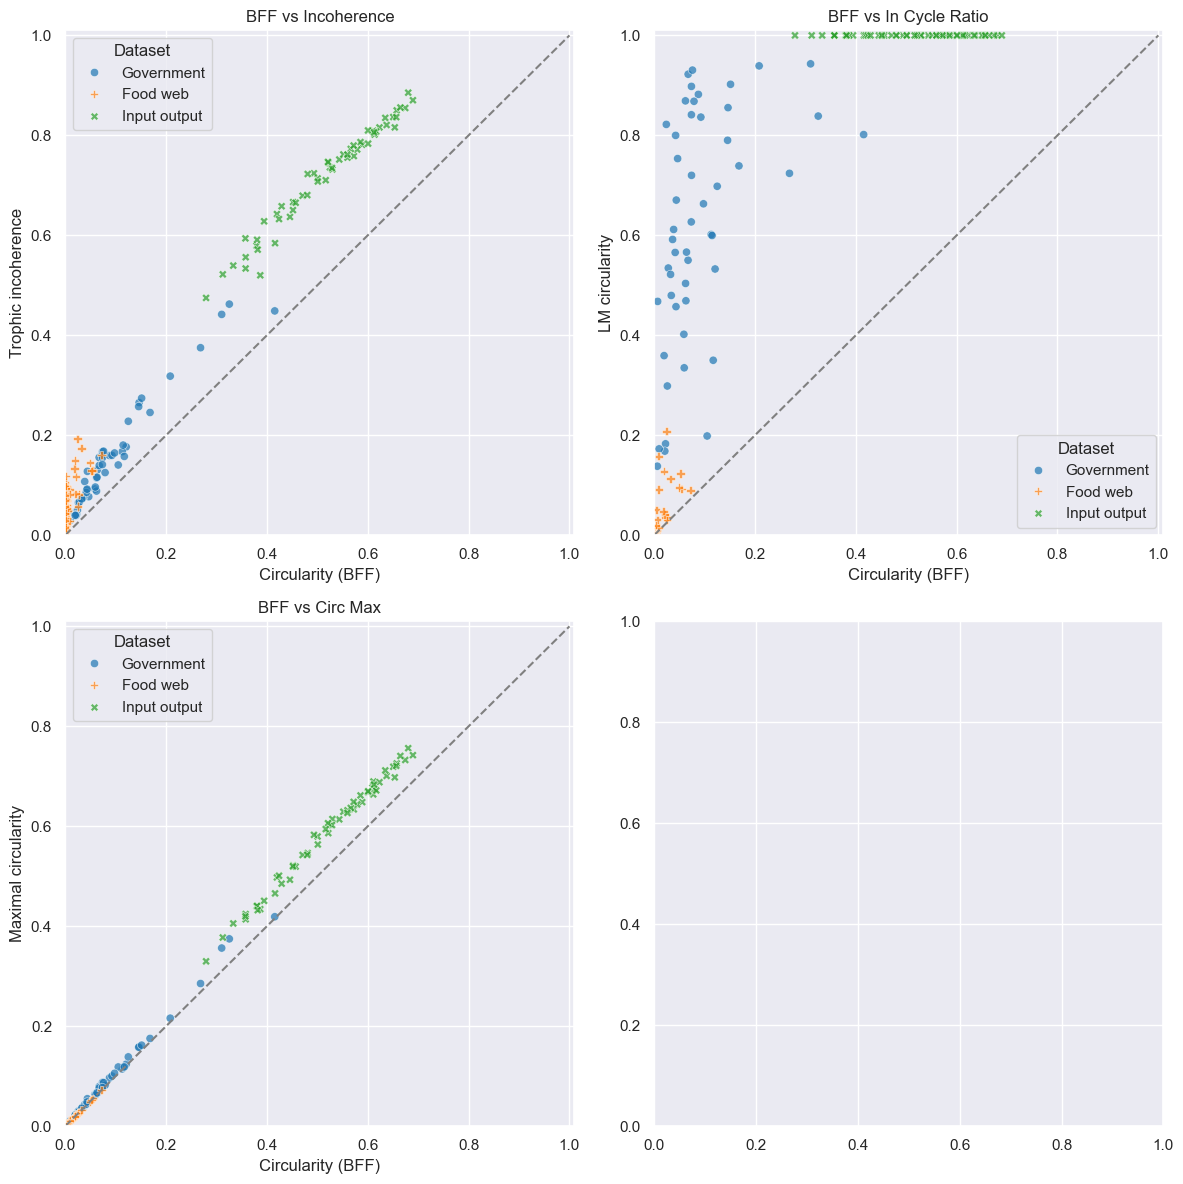

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load data if not already in memory
df    = pd.read_csv('government_analysis.csv')
df_fw = pd.read_csv('foodweb_analysis.csv')
df_io = pd.read_csv('io_analysis.csv')

# Tag each dataset
df['dataset']    = 'Government'
df_fw['dataset'] = 'Food web'
df_io['dataset'] = 'Input output'

# Combine into one DataFrame
combined = pd.concat([df, df_fw, df_io], ignore_index=True)
sns.set_theme(style="darkgrid")
measures = ['incoherence', 'in_cycle_ratio', 'circ_max']
measures_mapping= {'incoherence':'Trophic incoherence', 'in_cycle_ratio':'LM circularity', 'circ_max':'Maximal circularity'}
palette = {'Government':'tab:blue','Food web':'tab:orange', 'Input output':'tab:green'}
markers = {"Government" : "o", "Food web": "P", "Input output": "X"}
# Create 2×2 grid of scatter plots


fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, measure in zip(axes, measures):
    sns.scatterplot(
        data=combined,
        x='circ_bff',
        y=measure,
        hue='dataset',
        style='dataset',
        palette=palette,
        alpha=0.7,
        markers = markers,
        ax=ax
    )
    # y = x reference line
    ax.plot([0, 1], [0, 1], ls='--', c='gray')
    
    ax.set_title(f'BFF vs {measure.replace("_", " ").title()}')
    ax.set_xlim(0, 1.01)
    ax.set_ylim(0, 1.01)
    ax.set_xlabel('Circularity (BFF)')
    ax.set_ylabel(measures_mapping[measure])
    ax.legend(title='Dataset')

plt.tight_layout()
plt.show()